# Standardization


## **1. What is Standardization?**

**Standardization** (also called **Z-score normalization**) is a **data preprocessing technique** used to **rescale features** so that they have:

* **Mean = 0**
* **Standard Deviation = 1**

The formula for standardization is:

z= x-μ / σ

Where:

* (x) = original value
* (μ) = mean of the feature
* (σ) = standard deviation of the feature
* (z) = standardized value



Now the data is **centered around 0** with a **standard deviation of 1**.

---

## **2. Why Do We Use Standardization?**

Standardization is **important** in ML for several reasons:

### **a) Handles features with different scales**

* Many ML algorithms rely on **distances** (e.g., **KNN**, **SVM**, **K-Means**) or **gradients** (e.g., **Gradient Descent in Linear/Logistic Regression**, **Neural Networks**).
* If features are on different scales (e.g., age 20-60, salary 1000-100000), the algorithm will give **more importance to larger scale features**.
* Standardization ensures **all features contribute equally**.

---

### **b) Improves convergence in Gradient-based algorithms**

* Algorithms like **Linear Regression**, **Logistic Regression**, and **Neural Networks** use **gradient descent**.
* If features are on different scales, the **loss surface is skewed**, and gradient descent **converges slowly**.
* Standardization **speeds up convergence**.

---

### **c) Helps algorithms assuming normally distributed data**

* Some algorithms like **Linear Regression, Logistic Regression, PCA, LDA** assume data is **centered around 0**.
* Standardization makes data **closer to a normal distribution**, improving algorithm performance.

---

### **d) Reduces bias in distance-based algorithms**

* Algorithms like **KNN, K-Means, SVM** are **sensitive to the magnitude of features**.
* Standardization ensures no single feature dominates the distance metric.

---

## **3. When to Standardize**

* **Always** when features are on **different scales**.
* **Must** for algorithms sensitive to scale:

  * KNN
  * SVM
  * K-Means
  * PCA
  * Gradient Descent-based models
* **Not needed** for tree-based models like:

  * Decision Trees
  * Random Forest
  * XGBoost
    because these are **scale-invariant**.

---

## **4. Difference Between Standardization and Normalization**

| Aspect     | Standardization                         | Normalization (Min-Max Scaling)                  |
| ---------- | --------------------------------------- | ------------------------------------------------ |
| Formula    | (z = (x-\mu)/\sigma)                    | (x_{norm} = \frac{x - x_{min}}{x_{max}-x_{min}}) |
| Range      | No fixed range (depends on std dev)     | Fixed [0,1] or [-1,1]                            |
| Useful For | Algorithms assuming normal distribution | Algorithms needing bounded range                 |

---

✅ **Summary:**

Standardization transforms features to **zero mean and unit variance**.
It is crucial when features are on **different scales**, for **distance-based models**, and for **gradient descent-based optimization**. It ensures **faster convergence** and **better model performance**.






In [254]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive


In [255]:
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [256]:
df=pd.read_csv("/content/drive/MyDrive/Social_Network_Ads csv")

In [257]:
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [258]:
df=df.iloc[:,2:]
df.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [259]:
df.sample(5)

,Age,EstimatedSalary,Purchased
284,48,141000,0
55,24,55000,0
205,47,47000,0
19,48,29000,1
300,58,38000,1


In [260]:
df.shape

(400, 3)

In [261]:
x=df.drop('Purchased',axis=1)
y=df['Purchased']

In [262]:
x

,Age,EstimatedSalary
0,19,19000
1,35,20000
2,26,43000
3,27,57000
4,19,76000
...,...,...
395,46,41000
396,51,23000
397,50,20000
398,36,33000


In [263]:
y

,Purchased
0,0
1,0
2,0
3,0
4,0
...,...
395,1
396,1
397,1
398,0


# Train Test Split

In [264]:
from sklearn.model_selection import train_test_split

In [265]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3)

In [266]:
x_train.shape,x_test.shape

((280, 2), (120, 2))

# Standard Scaler

In [267]:
from sklearn.preprocessing import StandardScaler

In [268]:
scalar=StandardScaler()

# fit the scaler to the train set, it will learn the parameters
scalar.fit(x_train)

StandardScaler()

In [269]:
# transform train and test sets
x_train_scaled=scalar.transform(x_train)
x_test_scaled=scalar.transform(x_test)

In [270]:
scalar.mean_

array([3.75250000e+01, 6.92357143e+04])

In [271]:
x_train

,Age,EstimatedSalary
284,48,141000
341,35,75000
225,37,53000
229,42,80000
72,20,23000
...,...,...
254,50,44000
244,41,72000
12,20,86000
260,35,77000


In [272]:
x_train_scaled

array([[ 0.97504672,  2.2297061 ],
       [-0.23503513,  0.17909553],
       [-0.04886869, -0.50444132],
       [ 0.4165474 ,  0.33444482],
       [-1.63128341, -1.43653703],
       [-0.607368  , -0.10053318],
       [-1.81744984, -0.53551118],
       [-0.23503513, -0.59765089],
       [ 0.97504672, -1.21904803],
       [-0.04886869,  0.17909553],
       [ 0.13729775,  0.0548161 ],
       [ 0.23038097, -0.38016189],
       [ 0.78888028,  0.83156253],
       [-0.607368  , -1.0947686 ],
       [-0.97970088, -0.34909204],
       [-0.14195191, -1.12583846],
       [ 0.69579706, -0.75300018],
       [-1.81744984,  0.52086396],
       [-0.23503513,  2.41612524],
       [-0.04886869, -0.53551118],
       [ 1.99896212,  0.58300367],
       [-1.16586731,  0.30337496],
       [ 1.9058789 , -0.69086046],
       [ 1.44046281,  2.29184581],
       [-1.72436662,  0.4897941 ],
       [ 0.97504672,  2.13649652],
       [ 1.81279568, -0.28695232],
       [-1.07278409,  0.45872425],
       [-0.23503513,

In [273]:
x_train_scaled=pd.DataFrame(x_train_scaled,columns=x_train.columns)
x_test_scaled=pd.DataFrame(x_test_scaled,columns=x_test.columns)

In [274]:
x_train.describe()

,Age,EstimatedSalary
count,280.000000,280.000000
mean,37.525000,69235.714286
std,10.762311,32243.164531
min,18.000000,15000.000000
25%,29.000000,44750.000000
50%,37.000000,71000.000000
75%,46.000000,86000.000000
max,60.000000,149000.000000


In [275]:
x_train_scaled.describe()

,Age,EstimatedSalary
count,2.800000e+02,2.800000e+02
mean,1.157804e-16,-1.268826e-16
std,1.001791e+00,1.001791e+00
min,-1.817450e+00,-1.685096e+00
25%,-7.935344e-01,-7.607676e-01
50%,-4.886869e-02,5.481610e-02
75%,7.888803e-01,5.208640e-01
max,2.092045e+00,2.478265e+00


# Effect of Scaling

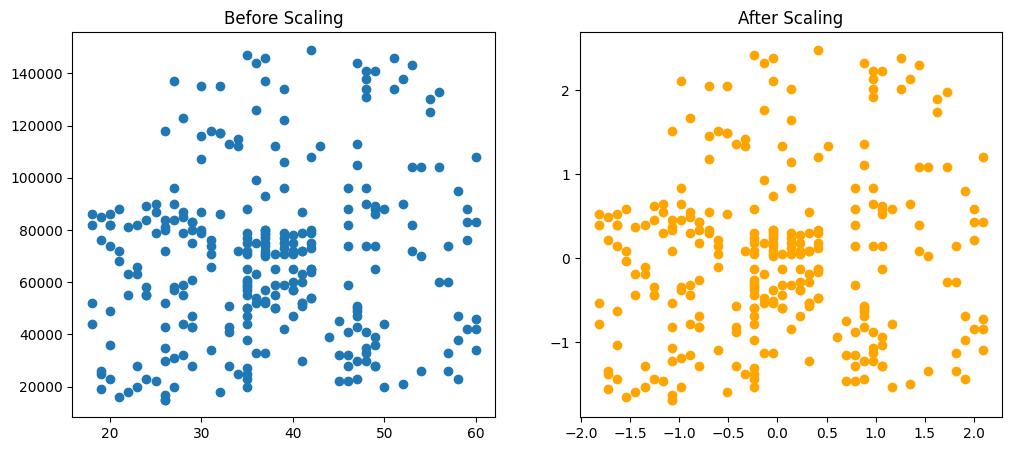

In [276]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))
ax1.scatter(x_train['Age'], x_train['EstimatedSalary'])
ax1.set_title("Before Scaling")
ax2.scatter(x_train_scaled['Age'], x_train_scaled['EstimatedSalary'],color='orange')
ax2.set_title("After Scaling")
plt.show()


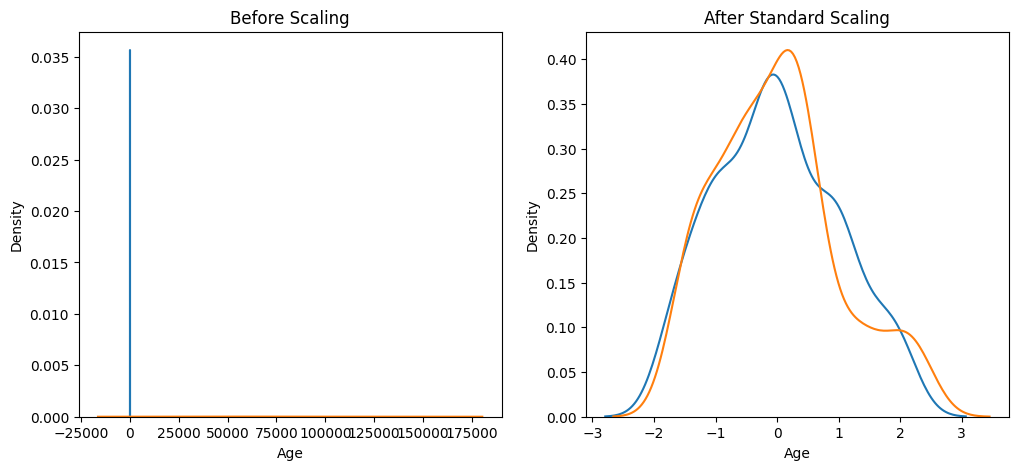

In [277]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))
# before scaling
ax1.set_title('Before Scaling')
sns.kdeplot(x_train['Age'], ax=ax1)
sns.kdeplot(x_train['EstimatedSalary'], ax=ax1)

# after scaling
ax2.set_title('After Standard Scaling')
sns.kdeplot(x_train_scaled['Age'], ax=ax2)
sns.kdeplot(x_train_scaled['EstimatedSalary'], ax=ax2)
plt.show()

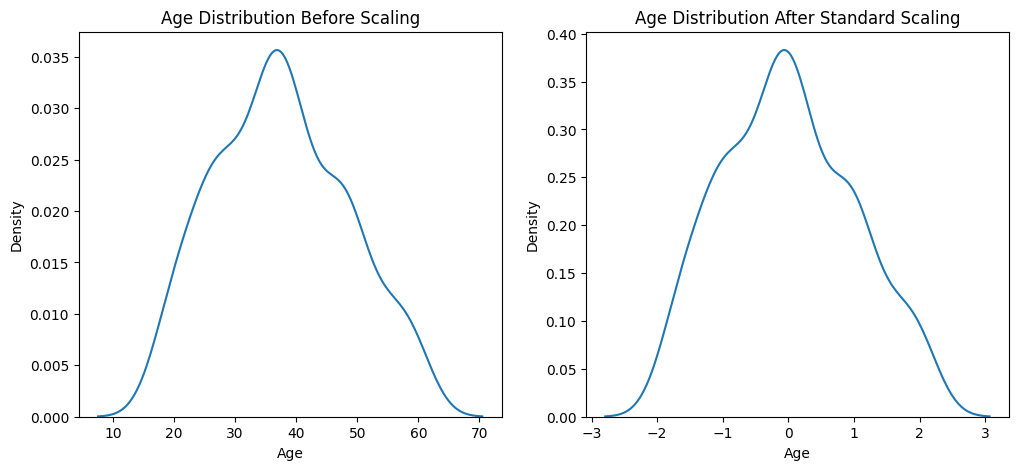

In [278]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))
# before scaling
ax1.set_title('Age Distribution Before Scaling')
sns.kdeplot(x_train['Age'], ax=ax1)
# after scaling
ax2.set_title('Age Distribution After Standard Scaling')
sns.kdeplot(x_train_scaled['Age'], ax=ax2)
plt.show()


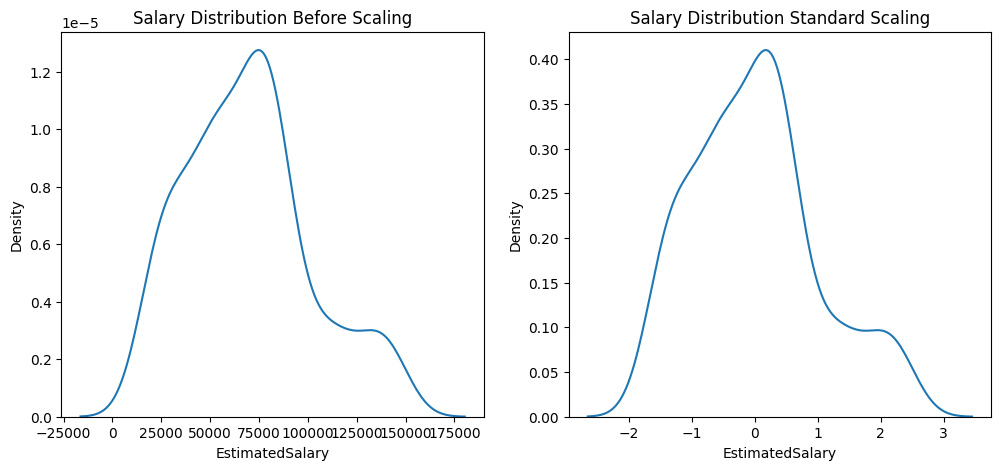

In [279]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))
# before scaling
ax1.set_title('Salary Distribution Before Scaling')
sns.kdeplot(x_train['EstimatedSalary'], ax=ax1)

# after scaling
ax2.set_title('Salary Distribution Standard Scaling')
sns.kdeplot(x_train_scaled['EstimatedSalary'], ax=ax2)
plt.show()

# Why scaling is important?

In [280]:
from sklearn.linear_model import LogisticRegression

In [281]:
lr=LogisticRegression()
lr_scaled=LogisticRegression()

In [282]:
lr.fit(x_train,y_train)
lr_scaled.fit(x_train_scaled,y_train)

LogisticRegression()

In [283]:
y_pred=lr.predict(x_test)
y_pred_scaled=lr.predict(x_test_scaled)

In [284]:
from sklearn.metrics import accuracy_score


In [285]:
print("Actual",accuracy_score(y_test,y_pred))
print("Scaled",accuracy_score(y_test,y_pred_scaled))


Actual 0.8583333333333333
Scaled 0.6166666666666667


In [286]:
from sklearn.tree import DecisionTreeClassifier


In [287]:
dt=DecisionTreeClassifier()
dt_scaled=DecisionTreeClassifier()

In [288]:
dt.fit(x_train,y_train)
dt_scaled.fit(x_train_scaled,y_train)


DecisionTreeClassifier()

In [289]:
y_pred=dt.predict(x_test)
y_pred_scaled=dt_scaled.predict(x_test_scaled)

In [290]:
print("Accuracy",accuracy_score(y_test,y_pred))
print("Scaled",accuracy_score(y_test,y_pred_scaled))

Accuracy 0.9
Scaled 0.9166666666666666


In [291]:
df.describe()

,Age,EstimatedSalary,Purchased
count,400.000000,400.000000,400.000000
mean,37.655000,69742.500000,0.357500
std,10.482877,34096.960282,0.479864
min,18.000000,15000.000000,0.000000
25%,29.750000,43000.000000,0.000000
50%,37.000000,70000.000000,0.000000
75%,46.000000,88000.000000,1.000000
max,60.000000,150000.000000,1.000000


#Effect of Outlier


In [293]:
df = df.append(pd.DataFrame({'Age':[5,90,95],'EstimatedSalary':[1000,250000,350000],'Purchased':[0,1,1]}),ignore_index=True)


AttributeError: 'DataFrame' object has no attribute 'append'

In [294]:
df

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0
...,...,...,...
395,46,41000,1
396,51,23000,1
397,50,20000,1
398,36,33000,0


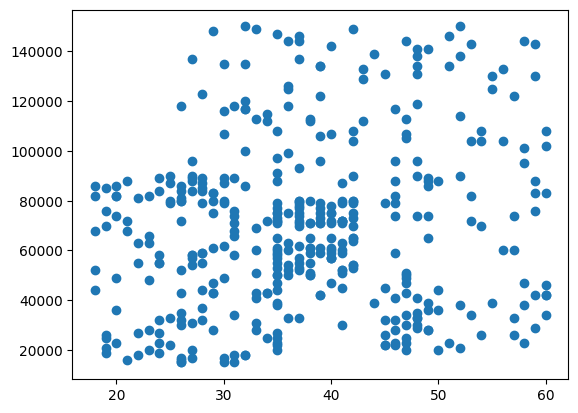

In [295]:
plt.scatter(df['Age'],df['EstimatedSalary'])

In [296]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.drop('Purchased', axis=1),df['Purchased'],test_size=0.3,random_state=0)

In [297]:
X_train.shape, X_test.shape


((280, 2), (120, 2))

In [300]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# fit the scaler to the train set, it will learn the parameters
scaler.fit(X_train)

# transform train and test sets
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [302]:
X_train_scaled=pd.DataFrame(X_train_scaled,columns=X_train.columns)
X_test_scaled=pd.DataFrame(X_test_scaled,columns=X_test.columns)

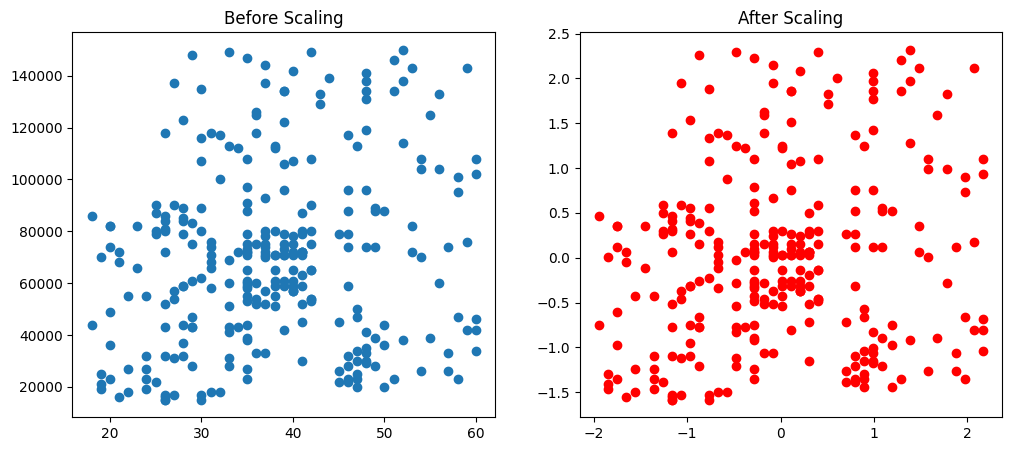

In [303]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

ax1.scatter(X_train['Age'], X_train['EstimatedSalary'])
ax1.set_title("Before Scaling")

ax2.scatter(X_train_scaled['Age'], X_train_scaled['EstimatedSalary'],color='red')
ax2.set_title("After Scaling")
plt.show()
